In [ ]:
import pandas as pd

In [17]:
class Perceptron:

    def __init__(self, weights, bias):
        self.weight = weights
        self.bias = bias

    def weightedsum(self, weights, input, bias):
        weightedsum = 0
        for i in range(len(weights)):
            weightedsum = weightedsum + (weights[i] * input[i])

        weightedsum = weightedsum + bias
        return weightedsum

    def activation(self, weightedsum):
        if weightedsum > 0:
            return 1
        else:
            return 0

    def predict(self, inputs):
        weightedsum = self.weightedsum(self.weight, inputs, self.bias)
        return self.activation(weightedsum)

    def backwardpass(self, input, target, learningrate):
        predicted = self.predict(input)

        error = target - predicted

        for i in range(len(self.weight)):
            self.weight[i] = self.weight[i] + learningrate * error * input[i]

        self.bias = self.bias + learningrate * error

In [2]:
import pandas as pd

df=pd.read_csv("data_banknote_authentication.txt",header=None,names=[
  "Variance","Skewness","Curtosis","Entropy","Class"])

In [3]:
df.head() #TO view the first 5 rows of the dataset

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [7]:
df.shape #TO know about dimension of the dataset

(1372, 5)

In [9]:
df.info() #TO know about column information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Variance  1372 non-null   float64
 1   Skewness  1372 non-null   float64
 2   Curtosis  1372 non-null   float64
 3   Entropy   1372 non-null   float64
 4   Class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [10]:
df.describe() #TO describe statistics

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [11]:
df.isnull().sum()

,0
Variance,0
Skewness,0
Curtosis,0
Entropy,0
Class,0


In [12]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

X=x.values
Y=y.values

In [14]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X=sc.fit_transform(X)

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [21]:
class Perceptron:

    def __init__(self, weights, bias):
        self.weight = weights
        self.bias = bias

    def weightedsum(self, weights, input, bias):
        weightedsum = 0
        for i in range(len(weights)):
            weightedsum = weightedsum + (weights[i] * input[i])

        weightedsum = weightedsum + bias
        return weightedsum

    def activation(self, weightedsum):
        if weightedsum > 0:
            return 1
        else:
            return 0

    def predict(self, inputs):
        weightedsum = self.weightedsum(self.weight, inputs, self.bias)
        return self.activation(weightedsum)

    def backwardpass(self, input, target, learningrate):
        predicted = self.predict(input)

        error = target - predicted

        for i in range(len(self.weight)):
            self.weight[i] = self.weight[i] + learningrate * error * input[i]

        self.bias = self.bias + learningrate * error

In [25]:
learning_rate = 0.1
epochs = 20
p = Perceptron([0,0,0,0],0)

error_history = []
weight_history = []
bias_history = []

for epoch in range(epochs):

    errors = 0

    for i in range(len(X_train)):

        prediction = p.predict(X_train[i])

        if prediction != Y_train[i]:
            errors += 1

        p.backwardpass(X_train[i],Y_train[i],learning_rate)

    error_history.append(errors)
    weight_history.append(p.weight.copy())
    bias_history.append(p.bias)

    print("Epoch",epoch+1)
    print("Errors:",errors)
    print("Weights:",p.weight)
    print("Bias:",p.bias)
    print()

Epoch 1
Errors: 52
Weights: [np.float64(-0.537244171631416), np.float64(-0.8095272313860578), np.float64(-0.7831015227542828), np.float64(0.031606047193455944)]
Bias: -0.20000000000000004

Epoch 2
Errors: 26
Weights: [np.float64(-0.7589629123371747), np.float64(-0.9751894651819409), np.float64(-0.8555766219141294), np.float64(-0.03907872331580489)]
Bias: -0.20000000000000004

Epoch 3
Errors: 20
Weights: [np.float64(-0.7951912235483415), np.float64(-0.9866861993652631), np.float64(-0.8739731239659227), np.float64(-0.0034157824846679924)]
Bias: -0.4

Epoch 4
Errors: 24
Weights: [np.float64(-0.799055071939853), np.float64(-1.3182946155284527), np.float64(-0.8723043138775358), np.float64(-0.03327736084719527)]
Bias: -0.4

Epoch 5
Errors: 23
Weights: [np.float64(-0.9805502098095848), np.float64(-1.2693395760115396), np.float64(-1.0907589147880303), np.float64(-0.09811879477738011)]
Bias: -0.30000000000000004

Epoch 6
Errors: 18
Weights: [np.float64(-1.0488537592442264), np.float64(-1.445019

In [26]:
correct = 0
predictions = []

for i in range(len(X_test)):

    prediction = p.predict(X_test[i])

    predictions.append(prediction)

    if prediction == Y_test[i]:
        correct += 1

accuracy = correct / len(X_test)

print("Accuracy:",accuracy*100,"%")

Accuracy: 98.18181818181819 %


In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy:", accuracy_score(Y_test, predictions))
print("Confusion Matrix:")
print(confusion_matrix(Y_test, predictions))
print("Precision:", precision_score(Y_test, predictions))
print("Recall:", recall_score(Y_test, predictions))
print("F1 Score:", f1_score(Y_test, predictions))

Accuracy: 0.9818181818181818
Confusion Matrix:
[[152   5]
 [  0 118]]
Precision: 0.959349593495935
Recall: 1.0
F1 Score: 0.979253112033195


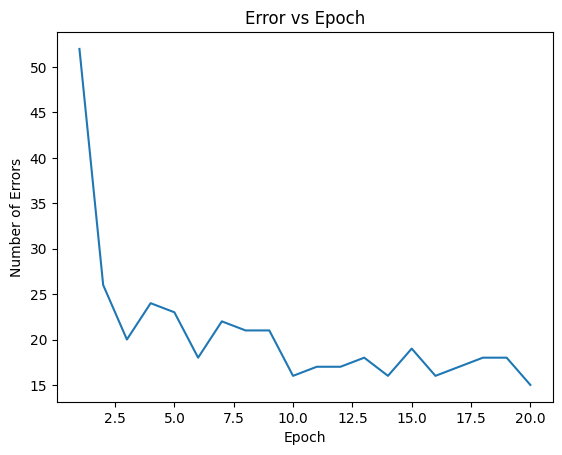

In [28]:
import matplotlib.pyplot as plt
plt.plot(range(1, epochs+1), error_history)

plt.title("Error vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Number of Errors")

plt.show()

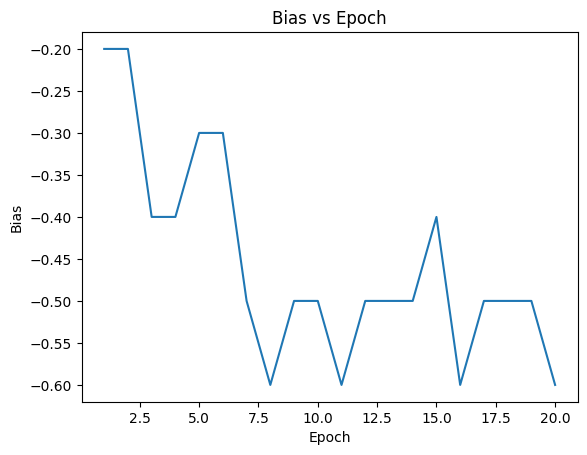

In [29]:
plt.plot(range(1, epochs+1), bias_history)

plt.title("Bias vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Bias")

plt.show()

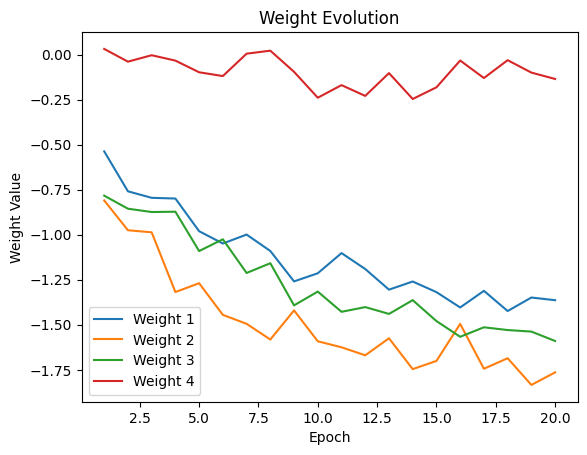

In [30]:
for i in range(len(weight_history[0])):
    plt.plot(range(1, epochs+1),
             [w[i] for w in weight_history],
             label="Weight "+str(i+1))

plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()

plt.show()

Learning Rate: 0.01
Accuracy: 0.9818181818181818
Learning Rate: 0.1
Accuracy: 0.9818181818181818
Learning Rate: 0.5
Accuracy: 0.9818181818181818


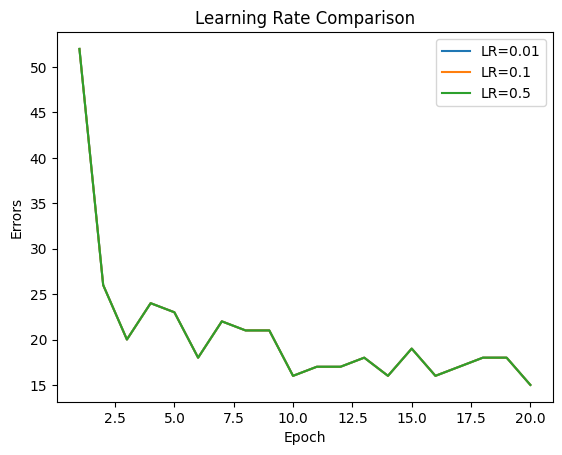

In [32]:
learning_rates = [0.01, 0.1, 0.5]

for lr in learning_rates:

    print("Learning Rate:", lr)

    p = Perceptron([0,0,0,0],0)

    error_history = []

    for epoch in range(epochs):

        errors = 0

        for i in range(len(X_train)):

            prediction = p.predict(X_train[i])

            if prediction != Y_train[i]:
                errors += 1

            p.backwardpass(X_train[i],Y_train[i],lr)

        error_history.append(errors)

    correct = 0

    for i in range(len(X_test)):

        prediction = p.predict(X_test[i])

        if prediction == Y_test[i]:
            correct += 1

    accuracy = correct/len(X_test)

    print("Accuracy:",accuracy)

    plt.plot(range(1,epochs+1),error_history,label="LR="+str(lr))

plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.legend()
plt.show()

In [34]:
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

model = Perceptron(max_iter=20,eta0=0.1,random_state=42,tol=None)
model.fit(X_train,Y_train)
prediction = model.predict(X_test)

print("Accuracy:",accuracy_score(Y_test,prediction))
print("Confusion Matrix")
print(confusion_matrix(Y_test,prediction))
print("Precision:",precision_score(Y_test,prediction))
print("Recall:",recall_score(Y_test,prediction))
print("F1 Score:",f1_score(Y_test,prediction))

Accuracy: 0.9890909090909091
Confusion Matrix
[[155   2]
 [  1 117]]
Precision: 0.9831932773109243
Recall: 0.9915254237288136
F1 Score: 0.9873417721518988


In [36]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, prediction))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       157
           1       0.98      0.99      0.99       118

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275



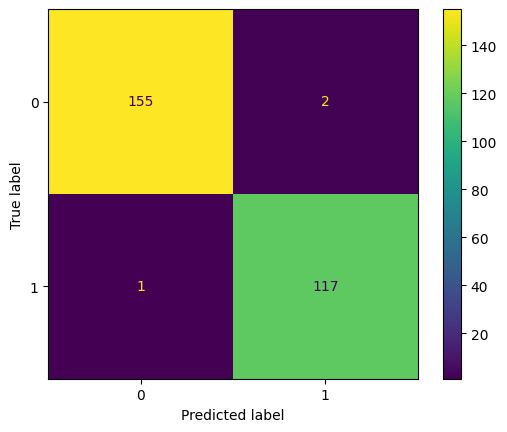

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(Y_test, prediction)

plt.show()

In [37]:
print("Our Perceptron")
print("Accuracy:",accuracy)
print()
print("Sklearn Perceptron")
print("Accuracy:",accuracy_score(Y_test,prediction))

Our Perceptron
Accuracy: 0.9818181818181818

Sklearn Perceptron
Accuracy: 0.9890909090909091
